In [1]:
import math, random
import gym
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
import torch.autograd as autograd
import torch.nn.functional as F
from torch.autograd import Variable
import numpy as np
if not hasattr(np, 'bool'):
    np.bool = np.bool_

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=

In [2]:
from IPython.display import clear_output
import matplotlib.pyplot as plt
%matplotlib inline

<h2>Replay Buffer</h2>

In [14]:
from collections import deque

class ReplayBuffer(object):
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        # Убираем expand_dims, так как state уже является массивом правильной формы
        # state уже имеет форму (4,) для CartPole
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        state, action, reward, next_state, done = zip(*random.sample(self.buffer, batch_size))
        # Преобразуем списки в numpy массивы
        return np.array(state), action, np.array(reward), np.array(next_state), done

    def __len__(self):
        return len(self.buffer)

<h2>Cart Pole Environment</h2>

In [5]:
env_id = "CartPole-v0"
env = gym.make(env_id)

/usr/local/lib/python3.12/dist-packages/gym/envs/registration.py:593: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(
/usr/local/lib/python3.12/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.12/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(


<h2>Epsilon greedy exploration</h2>

In [6]:
epsilon_start = 1.0
epsilon_final = 0.01
epsilon_decay = 500

epsilon_by_frame = lambda frame_idx: epsilon_final + (epsilon_start - epsilon_final) * math.exp(-1. * frame_idx / epsilon_decay)

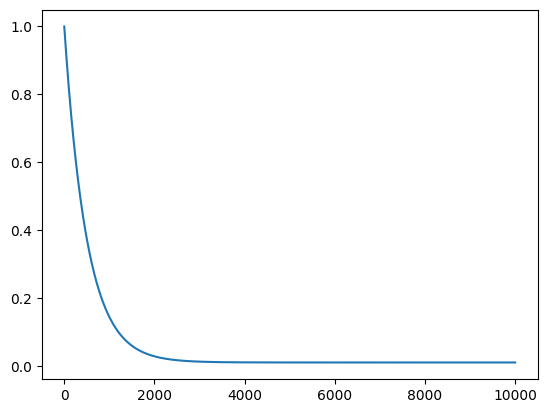

In [7]:
plt.plot([epsilon_by_frame(i) for i in range(10000)])

<h2>Deep Q Network</h2>

In [15]:
class DQN(nn.Module):
    def __init__(self, num_inputs, num_actions):
        super(DQN, self).__init__()

        self.layers = nn.Sequential(
            nn.Linear(env.observation_space.shape[0], 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, env.action_space.n)
        )

    def forward(self, x):
        return self.layers(x)

    def act(self, state, epsilon):
        if random.random() > epsilon:
            state = torch.FloatTensor(state).unsqueeze(0)
            with torch.no_grad():
                q_value = self.forward(state)
            action = q_value.max(1)[1].item()
        else:
            action = random.randrange(env.action_space.n)
        return action

In [16]:
model = DQN(env.observation_space.shape[0], env.action_space.n)
target_model = DQN(env.observation_space.shape[0], env.action_space.n)
target_model.load_state_dict(model.state_dict())

optimizer = optim.Adam(model.parameters())

replay_buffer = ReplayBuffer(1000)

<h2>Computing Temporal Difference Loss</h2>

In [28]:
def compute_td_loss(batch_size, buffer):
    batch, indices = buffer.sample(batch_size)
    state, action, reward, next_state, done = batch
    state = torch.FloatTensor(np.float32(state))
    next_state = torch.FloatTensor(np.float32(next_state))
    action = torch.LongTensor(action)
    reward = torch.FloatTensor(reward)
    done = torch.FloatTensor(done)

    q_values = model(state)
    next_q_values = model(next_state)

    q_value = q_values.gather(1, action.unsqueeze(1)).squeeze(1)
    next_q_value = next_q_values.max(1)[0]
    expected_q_value = reward + gamma * next_q_value * (1 - done)

    loss = (q_value - expected_q_value.detach()).pow(2).mean()
    prios = (q_value - expected_q_value.detach()).abs().pow(2).squeeze().cpu().detach().numpy() + 1e-6
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    buffer.update_priorities(indices, prios)

    return loss

In [23]:
def plot(frame_idx, rewards, losses):
    clear_output(True)
    plt.figure(figsize=(20,5))
    plt.subplot(131)
    plt.title('frame %s. reward: %s' % (frame_idx, np.mean(rewards[-10:])))
    plt.plot(rewards)
    plt.subplot(132)
    plt.title('loss')
    plt.plot(losses)
    plt.show()

<h2>Training</h2>

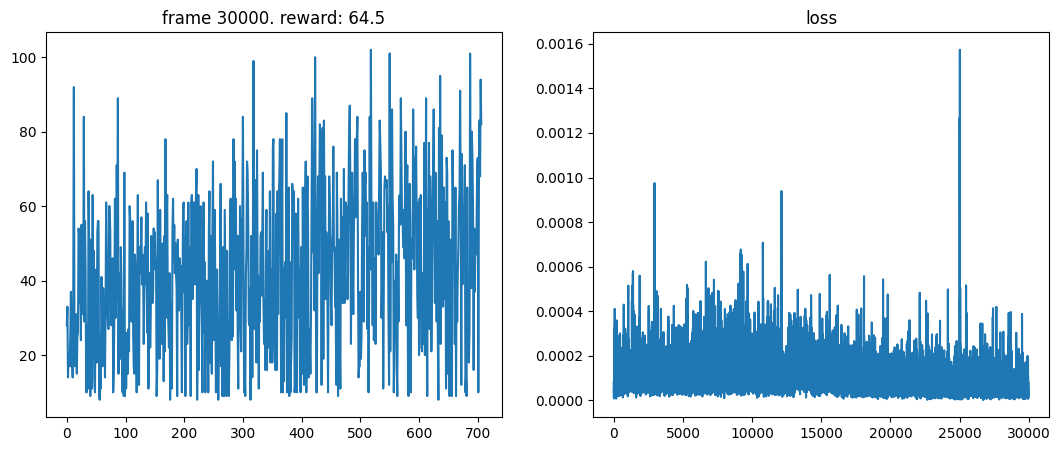

In [32]:
num_frames = 30000
batch_size = 32
gamma = 0.99

losses = []
all_rewards = []
episode_reward = 0

state = env.reset()
if isinstance(state, tuple):
    state = state[0]

replay_buffer = PrioBuf(10000)

for frame_idx in range(1, num_frames + 1):
    epsilon = epsilon_by_frame(frame_idx)
    action = model.act(state, epsilon)

    result = env.step(action)
    if len(result) == 4:
        next_state, reward, done, _ = result
    else:
        next_state, reward, terminated, truncated, _ = result
        done = terminated or truncated

    if isinstance(next_state, tuple):
        next_state = next_state[0]

    replay_buffer.push(state, action, reward, next_state, done)

    state = next_state
    episode_reward += reward

    if done:
        reset_result = env.reset()
        if isinstance(reset_result, tuple):
            state = reset_result[0]
        else:
            state = reset_result
        all_rewards.append(episode_reward)
        episode_reward = 0

    if len(replay_buffer) > batch_size:
      loss = compute_td_loss_prioritized(batch_size, replay_buffer)
      losses.append(loss.item())

    if frame_idx % 200 == 0:
        plot(frame_idx, all_rewards, losses)

<h2>Prioritized Replay Buffer (5 pts)</h2>

Не забудте про importance sampling

In [29]:
def compute_td_loss_prioritized(batch_size, buffer):
    batch, indices, weights = buffer.sample(batch_size)

    state = [x[0] for x in batch]
    action = [x[1] for x in batch]
    reward = [x[2] for x in batch]
    next_state = [x[3] for x in batch]
    done = [x[4] for x in batch]

    state = torch.FloatTensor(np.float32(state))
    next_state = torch.FloatTensor(np.float32(next_state))
    action = torch.LongTensor(action)
    reward = torch.FloatTensor(reward)
    done = torch.FloatTensor(done)
    weights = torch.FloatTensor(weights)

    q_values = model(state)
    next_q_values = target_model(next_state)

    q_value = q_values.gather(1, action.unsqueeze(1)).squeeze(1)
    next_q_value = next_q_values.max(1)[0]
    expected_q_value = reward + gamma * next_q_value * (1 - done)

    td_error = q_value - expected_q_value.detach()
    loss = (weights * td_error.pow(2)).mean()

    prios = td_error.abs().pow(2).squeeze().cpu().detach().numpy() + 1e-6

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    buffer.update_priorities(indices, prios)

    return loss

In [33]:
def upd_tgt(cur, tgt):
    tgt.load_state_dict(cur.state_dict())

In [34]:
b_start = 0.4
b_fr = 1000
b_by_fr = lambda fi: min(1.0, b_start + fi * (1.0 - b_start) / b_fr)

In [35]:
class PrioBuf:
    def __init__(self, maxlen):
        self.maxlen = maxlen
        self.buffer = []
        self.priorities = []
        self.alpha = 0.6
        self.beta_start = 0.4
        self.beta_frames = 100000
        self.frame = 0

    def push(self, s, a, r, ns, d):
        if len(self.buffer) == self.maxlen:
            self.buffer.pop(0)
            self.priorities.pop(0)
        self.buffer.append((s, a, r, ns, d))
        max_priority = max(self.priorities) if self.priorities else 1.0
        self.priorities.append(max_priority)

    def sample(self, batch_size):
        self.frame += 1
        beta = min(1.0, self.beta_start + self.frame * (1.0 - self.beta_start) / self.beta_frames)

        probs = np.array(self.priorities) ** self.alpha
        probs = probs / probs.sum()
        indices = np.random.choice(len(self.buffer), batch_size, p=probs)
        batch = [self.buffer[i] for i in indices]

        total = len(self.buffer)
        weights = (total * probs[indices]) ** (-beta)
        weights = weights / weights.max()

        return batch, indices, weights

    def update_priorities(self, indices, priorities):
        for idx, priority in zip(indices, priorities):
            if idx < len(self.priorities):
                self.priorities[idx] = priority + 1e-6

    def __len__(self):
        return len(self.buffer)

In [36]:
def act(self, state, epsilon):
    if random.random() > epsilon:
        if isinstance(state, tuple):
            state = state[0]

        if not isinstance(state, torch.Tensor):
            if isinstance(state, np.ndarray):
                state = torch.FloatTensor(state)
            else:
                state = torch.FloatTensor([state])

        if state.dim() == 1:
            state = state.unsqueeze(0)

        with torch.no_grad():
            q_value = self.forward(state)
        return q_value.max(1)[1].item()
    else:
        return random.randrange(self.action_size)

In [37]:
test_buffer = PrioBuf(100)
test_buffer.push(np.array([0,0,0]), 0, 1, np.array([0,0,0]), False)
print(type(test_buffer.sample(1)))
print(len(test_buffer.sample(1)))

<class 'tuple'>
3


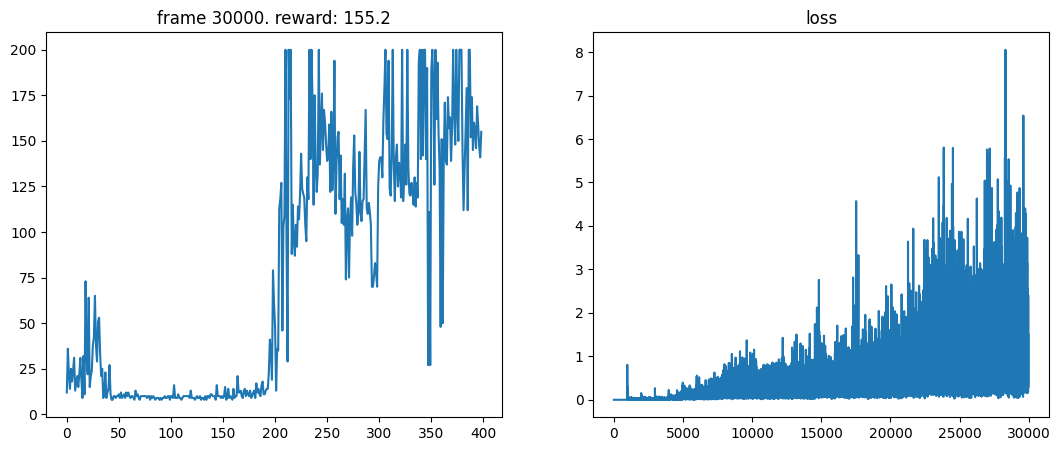

In [40]:
nf = 30000
bs = 32
g = 0.99

losses = []
all_rew = []
ep_rew = 0

s = env.reset()
replay_buffer = PrioBuf(10000)  # ← создаём буфер

for fi in range(1, nf + 1):
    eps = epsilon_by_frame(fi)

    if isinstance(s, tuple):
        current_state = s[0]
    else:
        current_state = s

    a = model.act(current_state, eps)

    res = env.step(a)
    if len(res) == 4:
        ns, r, d, _ = res
    else:
        ns, r, term, trunc, _ = res
        d = term or trunc

    if isinstance(ns, tuple):
        next_state = ns[0]
    else:
        next_state = ns

    replay_buffer.push(current_state, a, r, next_state, d)  # ← rb заменил на replay_buffer

    s = ns
    ep_rew += r

    if d:
        s = env.reset()
        all_rew.append(ep_rew)
        ep_rew = 0

    if len(replay_buffer) > bs:
        loss = compute_td_loss_prioritized(bs, replay_buffer)
        losses.append(loss.item())

    if fi % 1000 == 0:
        target_model.load_state_dict(model.state_dict())

    if fi % 200 == 0:
        plot(fi, all_rew, losses)

<p><hr></p>